In [23]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from torch import optim

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'

In [24]:
imagem1_pil = Image.open('dados/PR/dino_thunder.jpeg').resize((128, 128))
imagem2_pil = Image.open('dados/PR/tempestade_ninja.jpeg').resize((128, 128))
imagem3_pil = Image.open('dados/TS/1989_capa.png').resize((128, 128)).convert('RGB')
imagem4_pil = Image.open('dados/TS/Lover_capa.png').resize((128, 128)).convert('RGB')

imagem1_cinza_pil = imagem1_pil.convert('L').convert('RGB')
imagem2_cinza_pil = imagem2_pil.convert('L').convert('RGB')
imagem3_cinza_pil = imagem3_pil.convert('L').convert('RGB')
imagem4_cinza_pil = imagem4_pil.convert('L').convert('RGB')

transformacao = transforms.Compose([transforms.ToTensor()])

imagem1_cor = transformacao(imagem1_pil).unsqueeze(0).to(dispositivo)
imagem1_cinza = transformacao(imagem1_cinza_pil).unsqueeze(0).to(dispositivo)

imagem2_cor = transformacao(imagem2_pil).unsqueeze(0).to(dispositivo)
imagem2_cinza = transformacao(imagem2_cinza_pil).unsqueeze(0).to(dispositivo)

imagem3_cor = transformacao(imagem3_pil).unsqueeze(0).to(dispositivo)
imagem3_cinza = transformacao(imagem3_cinza_pil).unsqueeze(0).to(dispositivo)

imagem4_cor = transformacao(imagem4_pil).unsqueeze(0).to(dispositivo)
imagem4_cinza = transformacao(imagem4_cinza_pil).unsqueeze(0).to(dispositivo)

imagens_cinza = torch.cat([imagem1_cinza, imagem2_cinza, imagem3_cinza, imagem4_cinza], dim=0)
imagens_cor = torch.cat([imagem1_cor, imagem2_cor, imagem3_cor, imagem4_cor], dim=0)

In [25]:
class Identidade(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return x

class Desce(nn.Module):
    def __init__(self, canais_entrada, canais_saida):
        super().__init__()
        self.camada = nn.Sequential(
            nn.Conv2d(canais_entrada, canais_saida, kernel_size=3, padding=1),
            nn.BatchNorm2d(canais_saida),
            nn.ReLU(),
            nn.Conv2d(canais_saida, canais_saida, kernel_size=3, padding=1),
            nn.BatchNorm2d(canais_saida),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
    def forward(self, x):
        return self.camada(x)

class Sobe(nn.Module):
    def __init__(self, canais_entrada, canais_saida):
        super().__init__()
        self.camada_sobe = nn.ConvTranspose2d(canais_entrada, canais_saida, kernel_size=2, stride=2)
        self.camada_conv = nn.Sequential(
            nn.Conv2d(canais_entrada, canais_saida, kernel_size=3, padding=1),
            nn.BatchNorm2d(canais_saida),
            nn.ReLU(),
            nn.Conv2d(canais_saida, canais_saida, kernel_size=3, padding=1),
            nn.BatchNorm2d(canais_saida),
            nn.ReLU()
        )
    def forward(self, x, skip):
        x = self.camada_sobe(x)
        x = torch.cat([x, skip], dim=1)
        return self.camada_conv(x)

class ModeloColorir(nn.Module):
    def __init__(self):
        super().__init__()
        self.entrada = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.desce1 = Desce(64, 128)
        self.desce2 = Desce(128, 256)
        self.meio = Desce(256, 512)
        
        self.sobe1 = Sobe(512, 256)
        self.sobe2 = Sobe(256, 128)
        self.sobe3 = Sobe(128, 64) 
        
        self.saida = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        e = self.entrada(x)      
        d1 = self.desce1(e)       
        d2 = self.desce2(d1)      
        m = self.meio(d2)         
        
        s1 = self.sobe1(m, d2)    
        s2 = self.sobe2(s1, d1)   
        s3 = self.sobe3(s2, e)    
        
        return self.saida(s3)     

In [26]:
modelo = ModeloColorir().to(dispositivo)
otimizador = optim.Adam(modelo.parameters(), lr=1e-3)
funcao_erro = nn.MSELoss()

In [27]:
interacoes = 0
while interacoes < 500:
    otimizador.zero_grad()
    saida = modelo(imagens_cinza)
    erro = funcao_erro(saida, imagens_cor)
    erro.backward()
    otimizador.step()
    
    if interacoes % 50 == 0:
        print(erro.item())
        
    interacoes += 1

0.08715802431106567
0.0037529300898313522
0.0015663141384720802
0.0007384256459772587
0.00047648311010561883
0.00036743140663020313
0.00033585075289011
0.000378878612536937
0.00019292286015115678
0.0001444591471226886


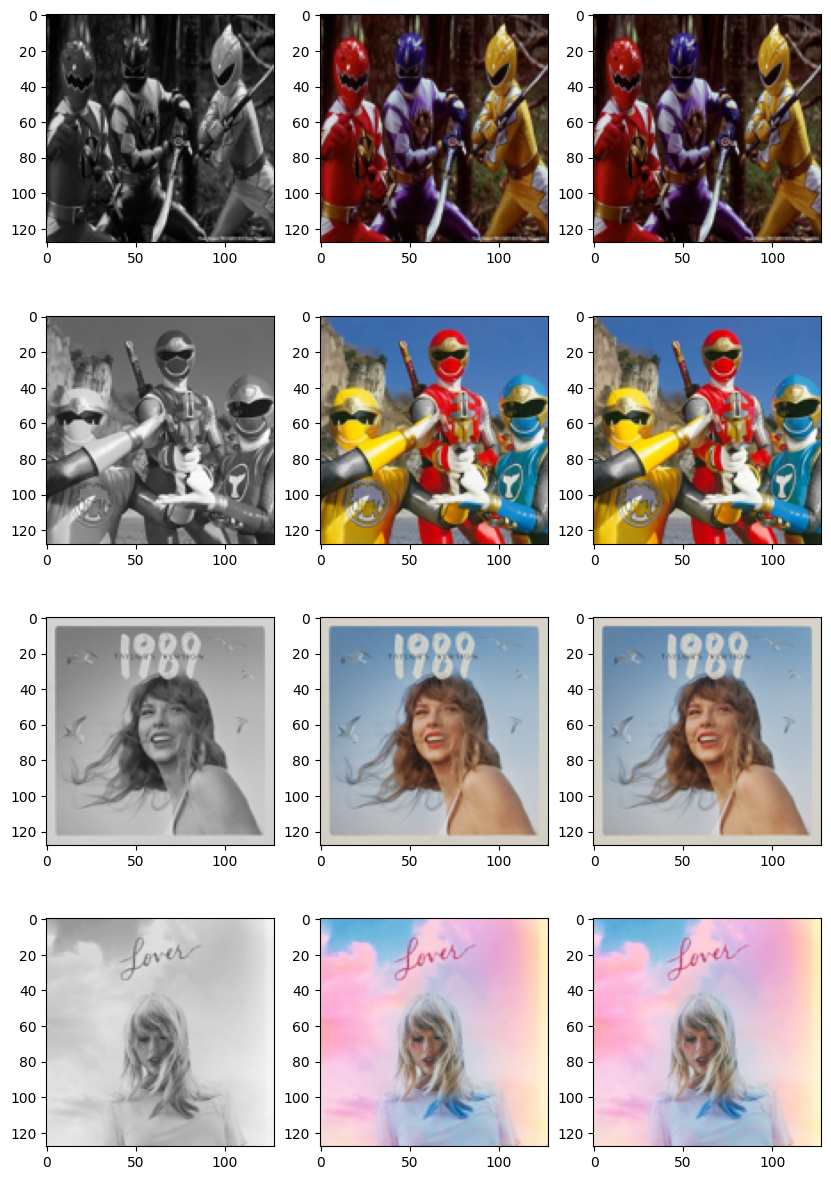

In [28]:
modelo.eval()
with torch.no_grad():
    saida_final = modelo(imagens_cinza)

figura, eixos = plt.subplots(4, 3, figsize=(10, 15))
for i in range(4):
    eixos[i, 0].imshow(imagens_cinza[i].permute(1, 2, 0).cpu().numpy())
    eixos[i, 1].imshow(saida_final[i].permute(1, 2, 0).cpu().numpy())
    eixos[i, 2].imshow(imagens_cor[i].permute(1, 2, 0).cpu().numpy())
plt.show()